# Q: Seq2Seq는 sos로 시작하고 eos로 마치는 구간까지의 센텐스를 예측 완료할 때까지 멈추지 않는다. 그렇다면 그 구간에 Gradient가 0으로 수렴하거나 망가질 수 있지 않을까?  
## A: 다음을 이용하여 그를 방지한다.
### 1. Teacher Forcing
학습할 때는 모델이 잘못된 단어를 뱉었다고 해서 그 단어를 다음 입력으로 쓰게 내버려 두지 않습니다.

작동 원리: 모델이 이상한 소리를 하더라도, 다음 단계의 입력으로는 실제 정답(Ground Truth) 단어를 강제로 넣어줍니다.

효과: 이를 통해 모델이 학습 초기에 엉뚱한 방향으로 빗나가서 전체 신경망이 망가지는 것을 방지합니다. 가이드라인을 따라가며 안정적으로 기울기(Gradient)를 계산할 수 있게 돕는 것이죠.
### 2. 추론 단계: 확률 기반의 선택 (Softmax)
모델의 출력층 끝에는 항상 Softmax 함수가 있습니다.

작동 원리: 디코더는 단순히 "0"이나 "1"을 내뱉는 것이 아니라, 단어장(Vocabulary)에 있는 모든 단어에 대해 확률을 계산합니다.

효과: 아무리 모델이 불확실하더라도 그중 '가장 확률이 높은 것'을 고르기 때문에, 수학적으로 계산값이 갑자기 0으로 완전히 사라지거나 무한대로 튀는 현상을 소프트맥스가 어느 정도 완충해 줍니다.  
### 3. 무한 루프 방지: 최대 길이 제한 (Max Length)
모델이 학습이 덜 되었거나 문맥을 놓쳐서 <eos>를 영원히 뱉지 않을 수도 있습니다. 이를 방지하기 위해 실무에서는 반드시 **최대 생성 길이(Max Step)**를 설정합니다.

예: "최대 100단어까지만 생성하고, 그래도 <eos>가 안 나오면 강제로 멈춰라"라는 코드를 넣습니다.  
### 4. 값이 0으로 수렴(Gradient Vanishing)하는 문제
이것은 질문하신 "생성 과정"보다는 "학습 과정"에서의 문제입니다.

RNN 계열의 한계: 문장이 길어질수록 앞서 말씀하신 기울기 소실(Gradient Vanishing) 때문에 컨텍스트 벡터의 영향력이 0에 가까워질 수 있습니다.

해결: 그래서 단순히 0으로 수렴하지 않도록 LSTM이나 GRU처럼 정보를 보존하는 '게이트' 구조를 사용하거나, 특정 시점의 단어를 직접적으로 참고하는 어텐션(Attention) 메커니즘을 사용합니다.

# Project: News summary

In [16]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)
print("NumPy:", np.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.10.1
NumPy: 1.26.4
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))


2.10.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
#!pip install --upgrade summa
#!pip install --upgrade nltk
#!pip install pandas
#!pip install --upgrade pip
#!pip install pandas numpy matplotlib scikit-learn urllib3
#!pip install torch==1.12.1+cu113 torchvision==0.13.1+cu113 torchaudio==0.12.1 --extra-index-url https://download.pytorch.org/whl/cu113
#!pip install ipykernel tensorflow
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

# 1. GPU 사용 가능 여부 (가장 중요: True가 나와야 함)
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")   

# 2. 현재 연결된 GPU 개수
print(f"GPU 개수: {torch.cuda.device_count()}")

# 3. GPU 모델명 확인
if torch.cuda.is_available():
    print(f"GPU 모델명: {torch.cuda.get_device_name(0)}")

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
raw_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
data = raw_data.copy()

data.sample(10)

CUDA 사용 가능: True
GPU 개수: 1
GPU 모델명: NVIDIA GeForce RTX 3060
3.9.4
1.12.1+cu113
2.3.3
1.2.0


,headlines,text
84589,Police station without a lockup chains convict...,The government railway police station in Rajas...
95899,Yogi Adityanath gets Z-plus category VVIP secu...,The Centre has accorded the top category Z-plu...
53064,Met my wife as a prostitute five years ago: Jo...,Cybersecurity expert John McAfee on Monday rev...
86832,"Shane Warne sledged me for 10 years, says Sour...",Former India captain Sourav Ganguly has said A...
53921,Spider web-inspired implant may help control t...,Taking inspiration from the way dew drops stic...
3879,11-month-old baby found alive after 35 hours u...,An 11-month-old baby boy was found alive after...
82107,Apple CEO mentions 'immigrants' in US Independ...,In what is being considered a dig at US Presid...
63789,Man arrested for raiding 50 hotel rooms in Spain,An Albanian national has been arrested by Span...
55106,Ratna Pathak slams actresses who star in films...,"Actress Ratna Pathak Shah, in a veiled referen..."
71893,Batsman's helmet goes flying after being struc...,Melbourne Stars captain John Hastings' helmet ...


## Step 1. 데이터 수집하기

`news_summary_more.csv` 파일을 성공적으로 로드했습니다. 이 데이터를 기반으로 요약 모델을 구축하겠습니다.

## Step 2. 데이터 전처리하기 (추상적 요약)

추상적 요약 모델 학습을 위해 텍스트 데이터를 정제하고 정규화하는 과정을 진행합니다. 불필요한 문자 제거, 소문자 변환, 불용어 제거 등을 통해 모델이 더 효율적으로 학습할 수 있도록 데이터를 준비합니다.

news_summary_more.csv 파일이 이미 존재합니다.
전처리 전 결측치 확인:
headlines    0
text         0
dtype: int64

결측치 제거 후:
headlines    0
text         0
dtype: int64

전처리 전 중복 샘플 개수: 22
중복 제거 후 샘플 개수: 98360


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\barab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



전처리 후 데이터 샘플:
                                           headlines  \
0  upgrad learner switches to career in ml al wit...   
1  delhi techie wins free food from swiggy for on...   
2  new zealand end rohit sharmaled indias match w...   
3  aegon life iterm insurance plan helps customer...   
4  have known hirani for yrs what if metoo claims...   

                                                text  
0  saurav kant alumnus upgrad iiitbs pg program m...  
1  kunal shahs credit card bill payment platform ...  
2  new zealand defeated india wickets fourth odi ...  
3  aegon life iterm insurance plan customers enjo...  
4  speaking sexual harassment allegations rajkuma...  

훈련 데이터 개수: 78688 테스트 데이터 개수: 19672


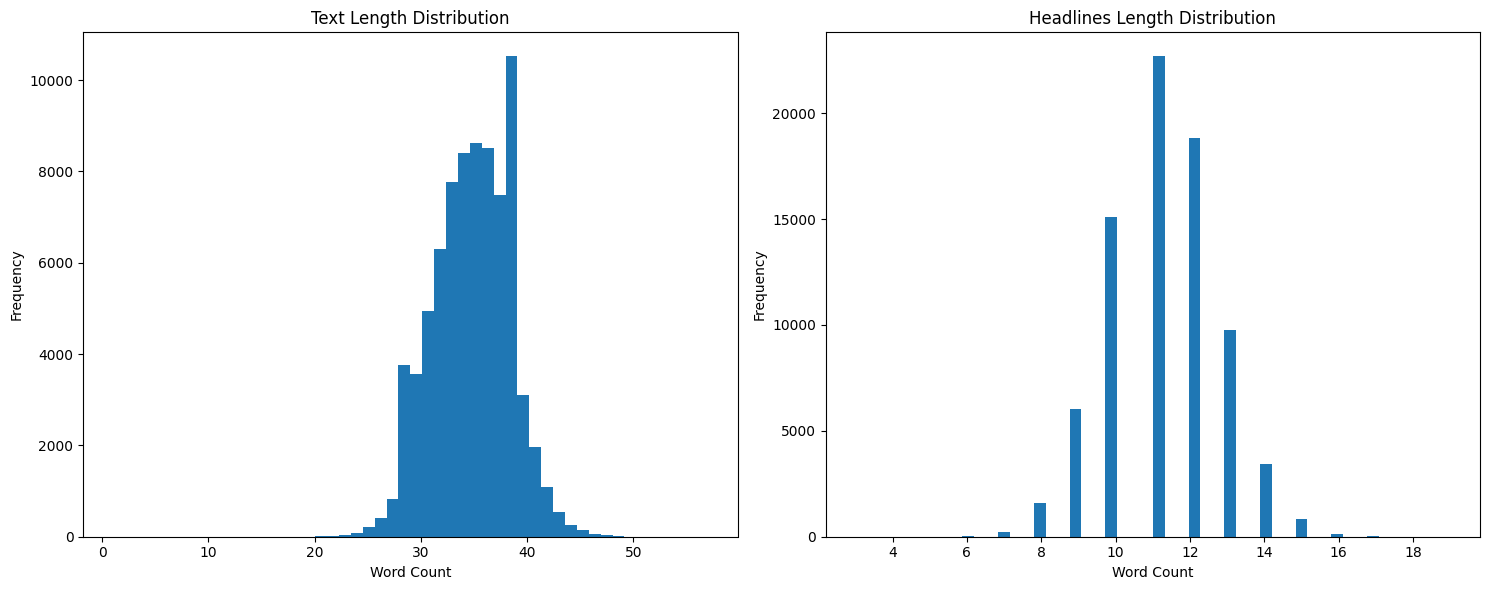

In [19]:

import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # pandas import 추가
import urllib.request # Add this import for urlretrieve
import os # To check if file exists before downloading
from sklearn.model_selection import train_test_split

# 데이터 로드 (NameError 방지를 위해 추가 및 파일 다운로드 추가)
file_path = 'news_summary_more.csv'
if not os.path.exists(file_path):
    print(f"{file_path} 파일이 없습니다. 다운로드합니다.")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename=file_path)
else:
    print(f"{file_path} 파일이 이미 존재합니다.")

raw_data = pd.read_csv(file_path, encoding='iso-8859-1')
data = raw_data.copy()

# 결측치 확인
print('전처리 전 결측치 확인:')
print(data.isnull().sum())

# text와 headlines 열에 있는 결측치 제거
data.dropna(axis=0, inplace=True)
print('\n결측치 제거 후:')
print(data.isnull().sum())

# 중복 샘플 확인 및 제거
print('\n전처리 전 중복 샘플 개수:', data.duplicated().sum())
data.drop_duplicates(subset = ['text'], inplace=True)
print('중복 제거 후 샘플 개수:', len(data))

# 텍스트 정규화를 위한 함수 정의
def preprocess_sentence(sentence):
    # HTML 태그 제거
    sentence = re.sub(r'<[^>]+>', '', sentence)
    # 소문자 변환
    sentence = sentence.lower()
    # 불필요한 특수 문자 제거 (알파벳과 공백만 남기기)
    sentence = re.sub(r'[^a-zA-Z ]', '', sentence)
    # 여러 개의 공백을 하나의 공백으로 대체
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    return sentence

# 불용어 제거를 위한 NLTK 다운로드 (처음 실행 시 필요)
import nltk
nltk.download('stopwords') # Uncommented this line to download stopwords
from nltk.corpus import stopwords

# 불용어 리스트 생성
stop_words = set(stopwords.words('english'))

def remove_stopwords(sentence):
    words = sentence.split()
    # 길이가 짧은 요약 데이터의 경우 불용어 제거는 핵심 정보를 잃을 수 있으므로 신중하게 판단해야 합니다.
    # 여기서는 본문(text)에 대해서만 불용어를 제거합니다.
    return ' '.join([word for word in words if word not in stop_words])

# 'text' 열 전처리 적용
data['text'] = data['text'].apply(preprocess_sentence)
data['text'] = data['text'].apply(remove_stopwords)

# 'headlines' 열 전처리 적용 (요약문은 불용어 제거 없이 정규화만 진행)
data['headlines'] = data['headlines'].apply(preprocess_sentence)

# 전처리된 데이터 확인
print('\n전처리 후 데이터 샘플:')
print(data.head())

# 훈련 데이터와 테스트 데이터 분리 (8:2 비율)
x_train, x_test, y_train, y_test = train_test_split(
    data['text'], data['headlines'], test_size=0.2, random_state=42
)

# 디코더용 시작/종료 토큰 추가
y_train = y_train.apply(lambda x: '<sos> ' + x + ' <eos>')
y_test = y_test.apply(lambda x: '<sos> ' + x + ' <eos>')
print(f'\n훈련 데이터 개수: {len(x_train)}', f'테스트 데이터 개수: {len(x_test)}')

# 텍스트 길이 분포 확인
text_word_counts = [len(sentence.split()) for sentence in x_train]
headlines_word_counts = [len(sentence.split()) for sentence in y_train]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(text_word_counts, bins=50)
ax1.set_title('Text Length Distribution')
ax1.set_xlabel('Word Count')
ax1.set_ylabel('Frequency')

ax2.hist(headlines_word_counts, bins=50)
ax2.set_title('Headlines Length Distribution')
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)

어텐션 메커니즘을 사용한 Seq2Seq 모델을 설계하기 위해, 먼저 텍스트 데이터를 숫자로 변환하는 토크나이저를 생성하고, 각 문장의 최대 길이를 설정하겠습니다. 이는 모델이 고정된 길이의 입력과 출력을 처리할 수 있도록 하는 중요한 전처리 과정입니다.

In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Source (뉴스 본문) 토크나이저 생성
# num_words: 가장 빈도가 높은 단어 수를 제한. OOV (Out-Of-Vocabulary) 토큰을 고려하여 조금 여유있게 설정
source_tokenizer = Tokenizer(num_words=None, oov_token='<unk>')
source_tokenizer.fit_on_texts(x_train) # 훈련 데이터에 맞춰 토크나이저 학습

# Target (헤드라인) 토크나이저 생성
# num_words: 요약문에 대한 단어 수를 제한. OOV 토큰과 함께 시작/끝 토큰을 고려하여 설정
target_tokenizer = Tokenizer(num_words=None, oov_token='<unk>')
target_tokenizer.fit_on_texts(y_train) # 훈련 데이터에 맞춰 토크나이저 학습

# 텍스트 데이터를 정수 시퀀스로 변환
x_train_seq = source_tokenizer.texts_to_sequences(x_train)
y_train_seq = target_tokenizer.texts_to_sequences(y_train)
x_test_seq = source_tokenizer.texts_to_sequences(x_test)
y_test_seq = target_tokenizer.texts_to_sequences(y_test)

# 단어 집합 크기 확인
source_vocab_size = len(source_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

print(f'뉴스 본문 단어 집합의 크기: {source_vocab_size}')
print(f'헤드라인 단어 집합의 크기: {target_vocab_size}')

# 훈련 데이터에서 가장 긴 문장의 길이 확인
max_text_len = max(len(seq) for seq in x_train_seq)
max_headlines_len = max(len(seq) for seq in y_train_seq)

print(f'뉴스 본문의 최대 길이: {max_text_len}')
print(f'헤드라인의 최대 길이: {max_headlines_len}')

# 패딩을 통해 시퀀스 길이 맞추기
# max_text_len, max_headlines_len을 적절하게 조정할 수 있습니다.
# 여기서는 분포를 확인했으므로, 그에 맞춰 설정합니다.
encoder_input_len = 100 # 예시로 설정한 길이, 실제 데이터 분포에 따라 조절 필요
decoder_input_len = 20 # 예시로 설정한 길이, 실제 데이터 분포에 따라 조절 필요

# 본문 시퀀스 패딩
X_train = pad_sequences(x_train_seq, maxlen=encoder_input_len, padding='post', truncating='post')
X_test = pad_sequences(x_test_seq, maxlen=encoder_input_len, padding='post', truncating='post')

# 요약 시퀀스 패딩
# 디코더 입력은 <sos>로 시작하고 <eos>로 끝나므로, 길이가 encoder_input_len 보다 짧은게 일반적입니다.
y_train_padded = pad_sequences(y_train_seq, maxlen=decoder_input_len, padding='post', truncating='post')
y_test_padded = pad_sequences(y_test_seq, maxlen=decoder_input_len, padding='post', truncating='post')

# 디코더의 입력과 출력 만들기
# 디코더 입력은 <sos>로 시작, 디코더 출력은 <eos>로 끝남
decoder_input = y_train_padded[:, :-1]
decoder_target = y_train_padded[:, 1:]

# 테스트 세트에 대해서도 동일하게 적용
decoder_input_test = y_test_padded[:, :-1]
decoder_target_test = y_test_padded[:, 1:]

print(f'훈련 데이터 본문 (Encoder Input) 형태: {X_train.shape}')
print(f'훈련 데이터 요약 (Decoder Input) 형태: {decoder_input.shape}')
print(f'훈련 데이터 요약 (Decoder Target) 형태: {decoder_target.shape}')

# 실제 단어와 정수 인덱스 매핑을 위한 사전 생성
source_word_to_index = source_tokenizer.word_index
source_index_to_word = {v: k for k, v in source_word_to_index.items()}
target_word_to_index = target_tokenizer.word_index
target_index_to_word = {v: k for k, v in target_word_to_index.items()}

print('\n토크나이저 및 패딩 완료.')

뉴스 본문 단어 집합의 크기: 93556
헤드라인 단어 집합의 크기: 35669
뉴스 본문의 최대 길이: 57
헤드라인의 최대 길이: 19
훈련 데이터 본문 (Encoder Input) 형태: (78688, 100)
훈련 데이터 요약 (Decoder Input) 형태: (78688, 19)
훈련 데이터 요약 (Decoder Target) 형태: (78688, 19)

토크나이저 및 패딩 완료.


### 모델 구축: 인코더-디코더 & 어텐션 메커니즘

 Seq2Seq 모델은 인코더와 디코더로 구성됩니다. 인코더는 입력 시퀀스를 벡터로 압축하고, 디코더는 이 벡터를 바탕으로 출력 시퀀스를 생성합니다. 여기에 어텐션 메커니즘을 추가하여 디코더가 매 시점마다 입력 시퀀스의 특정 부분에 더 집중할 수 있도록 하여 성능을 향상시킵니다.

In [21]:
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, Attention
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

embedding_dim = 128 # 임베딩 벡터의 차원
latent_dim = 256 # LSTM 은닉 상태의 차원

# --- 인코더 설계 ---
encoder_inputs = Input(shape=(encoder_input_len,))

# 임베딩 층
enc_emb = Embedding(source_vocab_size, embedding_dim)(encoder_inputs)

# 인코더 LSTM (return_state=True로 인코더의 은닉 상태와 셀 상태 반환)
encoder_lstm1 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

encoder_lstm2 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

encoder_lstm3 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4)
encoder_outputs, state_h, state_c = encoder_lstm3(encoder_output2)

# --- 디코더 설계 ---
decoder_inputs = Input(shape=(None,))

# 임베딩 층
dec_emb_layer = Embedding(target_vocab_size, embedding_dim)
dec_emb = dec_emb_layer(decoder_inputs)

# 디코더 LSTM (return_sequences=True로 모든 시점의 출력 반환, return_state=True로 은닉 상태와 셀 상태 반환)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# --- 어텐션 층 설계 ---
# Bahdanau 어텐션 (additive attention)
attention_layer = Attention()
attn_output = attention_layer([decoder_outputs, encoder_outputs])

# 디코더의 출력과 어텐션 결과 결합
decoder_concat_input = Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_output])

# 출력 층 (Softmax 활성화 함수로 단어 확률 예측)
decoder_softmax_layer = Dense(target_vocab_size, activation='softmax')
decoder_outputs = decoder_softmax_layer(decoder_concat_input)

# --- 모델 정의 ---
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 100)]        0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 100, 128)     11975168    ['input_6[0][0]']                
                                                                                                  
 lstm_4 (LSTM)                  [(None, 100, 256),   394240      ['embedding_2[0][0]']            
                                 (None, 256),                                                     
                                 (None, 256)]                                                     
                                                                                            

### 모델 학습

설계된 Seq2Seq 모델을 학습시키기 위해 옵티마이저와 손실 함수를 설정하고, `EarlyStopping` 콜백을 사용하여 과적합을 방지하고 학습을 효율적으로 진행합니다.

Epoch 1/100
308/308 [==============================] - 57s 168ms/step - loss: 4.0557 - val_loss: 3.7450 - lr: 0.0010
Epoch 2/100
308/308 [==============================] - 51s 165ms/step - loss: 3.6266 - val_loss: 3.5374 - lr: 0.0010
Epoch 3/100
308/308 [==============================] - 51s 165ms/step - loss: 3.4118 - val_loss: 3.3587 - lr: 0.0010
Epoch 4/100
308/308 [==============================] - 51s 165ms/step - loss: 3.2343 - val_loss: 3.2457 - lr: 0.0010
Epoch 5/100
308/308 [==============================] - 51s 165ms/step - loss: 3.0992 - val_loss: 3.1576 - lr: 0.0010
Epoch 6/100
308/308 [==============================] - 51s 165ms/step - loss: 2.9894 - val_loss: 3.0793 - lr: 0.0010
Epoch 7/100
308/308 [==============================] - 51s 165ms/step - loss: 2.8942 - val_loss: 3.0268 - lr: 0.0010
Epoch 8/100
308/308 [==============================] - 51s 165ms/step - loss: 2.8106 - val_loss: 2.9831 - lr: 0.0010
Epoch 9/100
308/308 [==============================] - 51s 165ms

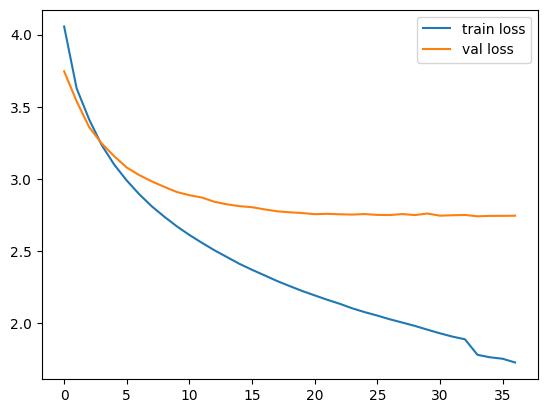


모델 학습 완료.


In [22]:
import torch

# 1. GPU 사용 가능 여부 확인 및 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')

es = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
rlp = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, mode='min')

history = model.fit(
    [X_train, decoder_input],
    decoder_target.reshape(decoder_target.shape[0], decoder_target.shape[1], 1),
    epochs=100,
    callbacks=[es, rlp],
    batch_size=256,
    validation_data=([X_test, decoder_input_test],
                     decoder_target_test.reshape(decoder_target_test.shape[0], decoder_target_test.shape[1], 1))
)

# 학습 곡선 시각화
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

print('\n모델 학습 완료.')

### 추론 모델 설계 (Inference Model)

학습된 Seq2Seq 모델을 사용하여 새로운 요약문을 생성하기 위한 추론 모델을 설계합니다. 인코더와 디코더를 분리하여 예측 과정에 맞게 재구성합니다.

In [23]:
# 인코더
encoder_model = Model(inputs=encoder_inputs, outputs=[encoder_outputs, state_h, state_c])

# 디코더의 이전 시점 상태를 보관할 변수
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))

decoder_hidden_state_input = Input(shape=(encoder_input_len, latent_dim))

# 디코더 임베딩
dec_emb2 = dec_emb_layer(decoder_inputs)

# 디코더 LSTM
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])

# 어텐션 층
attn_output2 = attention_layer([decoder_outputs2, decoder_hidden_state_input])
decoder_concat_input2 = Concatenate(axis=-1, name='concat_layer_infer')([decoder_outputs2, attn_output2])

# 디코더 출력 층
decoder_outputs2 = decoder_softmax_layer(decoder_concat_input2)

# 디코더 모델 정의
decoder_model = Model(
    [
        decoder_inputs, decoder_hidden_state_input,
        decoder_state_input_h, decoder_state_input_c
    ],
    [decoder_outputs2, state_h2, state_c2]
)

print('\n추론 모델 설계 완료.')


추론 모델 설계 완료.


### 요약문 생성 함수 (Seq2Seq Inference)

추론 모델을 사용하여 입력 텍스트로부터 요약문을 생성하는 함수를 구현합니다. 디코더가 `eos` 토큰을 생성하거나 최대 길이에 도달할 때까지 단어를 하나씩 예측합니다.

In [24]:
def decode_sequence(input_seq):
    e_out, e_h, e_c = encoder_model.predict(input_seq, verbose=0)

    target_sequence = np.zeros((1, 1))
    target_sequence[0, 0] = target_word_to_index['sos']

    stop_condition = False
    decoded_sentence = []

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict(
            [target_sequence, e_out, e_h, e_c], verbose=0
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = target_index_to_word.get(sampled_token_index, '<unk>')

        if sampled_token not in ['sos', 'eos', '<unk>']:
            decoded_sentence.append(sampled_token)

        if (
            sampled_token == 'eos' or
            len(decoded_sentence) >= decoder_input_len - 1 or
            sampled_token_index == 0
        ):
            stop_condition = True

        target_sequence = np.zeros((1, 1))
        target_sequence[0, 0] = sampled_token_index

        e_h, e_c = h, c

    return ' '.join(decoded_sentence)

## Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)

이제 학습된 모델과 정의된 추론 함수를 사용하여 테스트 데이터의 뉴스 본문에 대한 요약문을 생성하고, 실제 헤드라인과 비교하여 모델의 성능을 평가합니다.

In [25]:
def summarize_text(input_text):
    # 입력 텍스트 전처리 (훈련 데이터와 동일하게)
    preprocessed_text = preprocess_sentence(input_text)
    preprocessed_text = remove_stopwords(preprocessed_text)

    # 텍스트를 정수 시퀀스로 변환
    input_seq = source_tokenizer.texts_to_sequences([preprocessed_text])

    # 패딩
    input_seq = pad_sequences(input_seq, maxlen=encoder_input_len, padding='post', truncating='post')

    # 요약문 생성
    summary = decode_sequence(input_seq)
    return summary

print('\n샘플 요약문 생성 시작...')

for i in range(10):
    print(f"원본 텍스트: {x_test.iloc[i][:500]}...") # 긴 텍스트는 일부만 출력
    print(f"실제 헤드라인: {y_test.iloc[i]}")
    generated_summary = summarize_text(x_test.iloc[i])
    print(f"생성된 요약: {generated_summary}\n")

print('\n추상적 요약 결과 비교 완료.')


샘플 요약문 생성 시작...
원본 텍스트: digital payments startup paytm raised billion softbank indias largest funding round also softbanks biggest investment indian startup ecosystem till date latest investment softbank value paytm around billion valuation billion august...
실제 헤드라인: <sos> paytm raises billion from softbank in largest funding <eos>
생성된 요약: paytm valuation raises billion in its funding

원본 텍스트: oil companies thursday reduced petrol price litre diesel litre effective june first cut prices following decision revise fuel prices daily revision shall applicable next day customers know revised prices social media posts fuelioc app...
실제 헤드라인: <sos> petrol price cut by per litre as daily revision starts <eos>
생성된 요약: petrol price hits litre diesel in diesel at

원본 텍스트: indian army announced plans deploy women officers cyber warfare face cybersecurity threats state nonstate actors order increase number female officers provide opportunities army also planning hire women military police branch l

## 결과 해석
seq2seq와 어텐션을 이용하여 추상적 요약을 실제 헤드라인과 비교해본 결과,  
생각보다 만족스러운 결과는 나오지 않았다.  
1. 핵심 정보는 일부 잡음
2. 환각(hallucination)과 의미 왜곡이 있음
3. 반복 표현이 많음
4. 문법적으로 부자연스러움

## Step 5. Summa를 이용해서 추출적 요약해보기


In [27]:
from summa.summarizer import summarize

print('\n추출적 요약 생성 시작...')

for i in range(10):
    original_text = raw_data['text'].iloc[i]
    actual_headline = raw_data['headlines'].iloc[i]

    # 짧은 기사에서는 ratio 대신 words 권장
    extractive_summary = summarize(original_text, words=30)

    # 빈 문자열 방지용 fallback
    if not extractive_summary.strip():
        sentences = summarize(original_text, split=True)
        if len(sentences) > 0:
            extractive_summary = ' '.join(sentences[:1])
        else:
            # 최후 fallback: 첫 문장만 사용
            extractive_summary = original_text.split('. ')[0].strip()

    abstractive_summary = summarize_text(original_text)

    print(f"원본 텍스트: {original_text[:500]}...")
    print(f"실제 헤드라인: {actual_headline}")
    print(f"추상적 요약: {abstractive_summary}")
    print(f"추출적 요약 (Summa): {extractive_summary}\n")

print('\n추출적 요약 및 비교 완료.')


추출적 요약 생성 시작...
원본 텍스트: Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers....
실제 헤드라인: upGrad learner switches to career in ML & Al with 90% salary hike
추상적 요약: upgrad ranked ai program to career ai with ai program
추출적 요약 (Summa): The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike.
upGrad's Online Power Learning has powered 3 lakh+ careers.

원본 텍스트: Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill 

## Step 6. 추상적 요약과 추출적 요약 결과 비교 및 분석

생성된 **추상적 요약(Abstractive Summary)**과 **추출적 요약(Extractive Summary, Summa)** 결과를 실제 뉴스 헤드라인과 비교하여 문장 자연성, 핵심 정보 전달, 요약 방식의 특징을 중심으로 분석하였다.

| 비교 항목 | 추상적 요약 (Abstractive Summary) | 추출적 요약 (Extractive Summary, Summa) |
|---|---|---|
| **문법 완성도** | 새로운 문장을 생성하지만 일부 문장에서 반복 표현이나 어색한 문장이 발생하였다. | 원문 문장을 그대로 사용하기 때문에 문법적으로 자연스럽고 오류가 거의 없다. |
| **핵심 단어 포함** | 일부 핵심 단어는 포함되었으나 의미가 왜곡되거나 핵심 사건을 정확히 반영하지 못하는 경우가 있었다. | 원문에서 중요한 문장을 선택하기 때문에 주요 단어가 포함되는 경우가 많지만, 항상 핵심 문장을 선택하지는 못하였다. |
| **정보 정확성** | 모델이 문장을 생성하는 과정에서 원문에 없는 내용이 등장하는 환각(hallucination)이 나타나기도 했다. | 원문 문장을 그대로 사용하므로 사실 왜곡이 발생하지 않는다. |
| **간결성** | 문장을 새롭게 생성하여 비교적 짧은 요약문을 만들 수 있지만 내용 정확성이 떨어질 수 있다. | 선택된 문장 길이에 따라 요약 길이가 달라지며, 헤드라인처럼 간결하게 압축되지 않는 경우가 많다. |

### 분석 결과

실험 결과를 보면 추상적 요약 모델은 문장을 새롭게 생성할 수 있다는 장점이 있지만, 실제 생성된 요약에서는 반복 표현이나 의미 왜곡이 발생하는 경우가 확인되었다. 예를 들어 일부 기사에서는 원문과 관련 없는 단어나 사건이 생성되거나 문장이 어색하게 구성되는 문제가 나타났다.

반면 추출적 요약(Summa)은 원문 문장을 그대로 선택하기 때문에 문법적으로 자연스럽고 사실 왜곡이 발생하지 않는 장점이 있었다. 그러나 실제 결과에서는 기사에서 가장 중요한 문장을 선택하지 못하는 경우도 관찰되었으며, 선택된 문장이 헤드라인처럼 핵심 내용을 압축적으로 전달하지 못하는 경우도 있었다.

따라서 본 실험에서는 **추출적 요약이 문법 안정성과 정보 정확성 측면에서는 우수했지만, 핵심 정보 선택 정확도와 간결성 측면에서는 한계가 나타났다.** 또한 **추상적 요약 모델은 문장을 생성할 수 있다는 장점이 있으나 현재 모델 구조와 학습 수준에서는 의미 왜곡과 반복 문제가 발생하여 성능 개선이 필요함을 확인하였다.**

결론적으로 두 방식은 서로 다른 장단점을 가지며, 실제 응용에서는 **추출적 요약을 기반으로 핵심 문장을 선택한 뒤 추상적 요약 모델을 활용하여 문장을 재구성하는 방식의 결합 접근법**이 효과적일 수 있다.